# Autoencoder Training

This notebook trains a convolutional autoencoder on **normal data** (no chatter).  
The model learns a compact representation and attempts to reconstruct the input images.  
Because anomalous samples (chatter) are not seen during training, we expect them to yield a **higher reconstruction error**.

**Core idea:** anomaly score = reconstruction error (e.g., MSE) between the input and its reconstruction.

In [1]:
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

REPO_ROOT = Path("..").resolve()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from spectrogram_anomaly_ae.cnn_autoencoder import (
    CNNAutoencoder,
    count_parameters,
    get_device,
    reconstruct_images,
    save_autoencoder,
    set_seed,
    train_autoencoder,
)

In [2]:
# =========================
# Reproducibility (Seeds)
# =========================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
set_seed(SEED)

# =========================
# Device check (optional)
# =========================
DEVICE = get_device()
print(f"PyTorch device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(DEVICE)}")
else:
    print("No CUDA GPU found; training on CPU.")

PyTorch device: cpu
No CUDA GPU found; training on CPU.


## Data

The spectrograms are loaded as images.

We distinguish between:
- **GOOD / Normal**: samples without chatter (used for training)
- **BAD / Chatter**: potentially anomalous samples (typically used for evaluation)

This notebook trains the autoencoder using **only the normal (GOOD)** class.

In [3]:
DATASET_NAME = "cnc_machining"  # options: "turning", "cnc_machining"

DATASET_CONFIGS = {
    "turning": {
        "train_nominal_dir": Path("../data/02_spectrograms_150x100px_dataset/train/no_chatter"),
        "model_path": Path("../models/ae_bn16_20260616.pt"),
    },
    "cnc_machining": {
        "train_nominal_dir": Path("../data/02_spectrograms_150x100px_cnc_machining_dataset/train/nominal"),
        "model_path": Path("../models/ae_bn16_cnc_machining_seed42.pt"),
    },
}

DATA_GOOD = DATASET_CONFIGS[DATASET_NAME]["train_nominal_dir"]
MODEL_PATH = DATASET_CONFIGS[DATASET_NAME]["model_path"]

In [4]:
def load_images_from_folder(folder, target_size=(150, 100)):
    """
    Load all images from a folder, resize them to target_size,
    convert to RGB, and return a NumPy array of shape (N, H, W, C).
    """
    images = []
    valid_ext = ('.png', '.jpg', '.jpeg')

    for file in tqdm(os.listdir(folder)):
        if file.lower().endswith(valid_ext):
            path = os.path.join(folder, file)
            img = Image.open(path).convert("RGB").resize(target_size)
            images.append(np.array(img))

    return np.array(images)

Load only normal data!

In [5]:
images = load_images_from_folder(DATA_GOOD)

# Normalize to [0, 1]
images = images.astype("float32") / 255.0
print("Loaded normal samples:", images.shape)

# Split into training and validation sets (only normal data)
x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train:", x_train.shape)
print("Val:", x_val.shape)

100%|██████████| 1142/1142 [00:00<00:00, 1856.71it/s]


Loaded normal samples: (1142, 100, 150, 3)
Train: (913, 100, 150, 3)
Val: (229, 100, 150, 3)


## Visualization / Sanity Check

To verify the data pipeline, we visualize one example spectrogram from the training set.
This helps confirm that resizing and normalization behave as expected.

In [6]:
fig = px.imshow(x_train[10])
fig.update_layout(coloraxis_showscale=False)
fig.show()

## Model: Convolutional Autoencoder

The autoencoder consists of three parts: 

1. **Encoder**: extracts features using convolutions and progressively reduces spatial dimensions
2. **Bottleneck**: compresses the representation using a dense layer
3. **Decoder**: reconstructs the input via dense expansion, reshaping, upsampling, and convolutions

### Training objective
The model minimizes the reconstruction error (MSE) between the input image $x$ and its reconstruction $\hat{x}$.

During anomaly detection, the reconstruction error is used as an anomaly score.

In [14]:
autoencoder = CNNAutoencoder(latent_dim=16).to(DEVICE)
print(autoencoder)
print(f"Trainable parameters: {count_parameters(autoencoder):,}")

CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=True)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 3), stride=(2, 3), padding=0, dilation=1, ceil_mode=True)
    (6): Conv2d(8, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=7500, out_features=16, bias=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=7500, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(12, 25, 25))
    (3): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Upsample(scale_factor=(2.0, 3.0), mode='nearest')
    (6): Conv2d(12, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

## Training Setup

- **Optimizer:** Adam with a small learning rate
- **Loss:** Mean Squared Error (MSE), measuring reconstruction quality

Because the autoencoder is trained on normal data only, anomalous inputs are expected to produce larger reconstruction errors.

In [15]:
history = train_autoencoder(
    autoencoder,
    x_train,
    x_val,
    epochs=4000,
    batch_size=32,
    learning_rate=1e-4,
    device=DEVICE,
    seed=SEED,
    progress=True,
    early_stopping=True,
    patience=100,
    min_delta=1e-6,
    restore_best_weights=True,
)

Training CNN-AE:   0%|          | 0/4000 [00:00<?, ?it/s]

## Reconstruction on a Sample

To qualitatively verify the training, we select a single validation sample and run the autoencoder to obtain its reconstruction.  
We then compute the reconstruction error (MSE) between the original input and the reconstructed output.


Reconstruction MSE: 0.005973


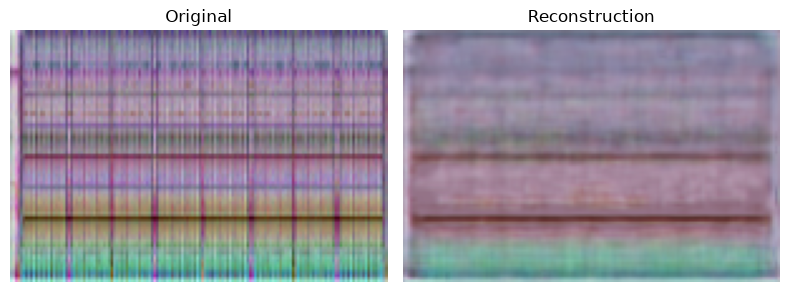

In [16]:
# -----------------------------
# Sample selection
# -----------------------------
idx = 62  # choose any index in the validation set
sample = x_val[idx]
sample_input = np.expand_dims(sample, axis=0)  # shape: (1, H, W, C)

# -----------------------------
# Reconstruction
# -----------------------------
recon = reconstruct_images(autoencoder, sample_input, batch_size=1, device=DEVICE)[0]

# -----------------------------
# Reconstruction Error (MSE)
# -----------------------------
mse = np.mean((sample - recon) ** 2)
print(f"Reconstruction MSE: {mse:.6f}")

# -----------------------------
# Visualization: original vs reconstruction
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(sample)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(recon)
axs[1].set_title("Reconstruction")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Saving the Trained Model

To enable reuse and reproducibility, we save the trained autoencoder to disk.  
The saved model can later be loaded for evaluation on anomalous data or for inference in other scripts.

In [17]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_PATH

# -----------------------------
# Save the trained model
# -----------------------------
save_autoencoder(autoencoder, model_path, history=history)

print(f"Model saved to: {model_path}")

Model saved to: ../models/ae_bn16_cnc_machining_seed42.pt
